# **Triage Copilot Model**
by Marcos Salazar



**Purpose:**

This notebook trains a machine learning pipeline (TF-IDF + LinearSVC) to classify bilingual student inquiries into 6 administrative categories (Admissions, Advising, Financial Services, ESL, Navigate, Appointment).

**Expected Outcomes:**

The trained Scikit-learn pipeline for the FastAPI backend. (model.joblib)

AND

The cleaned reference dataset for the learning feedback loop. (training_data.csv)

Installing Scikit-learn.

In [ ]:
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 29.5 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Importing the library and verifying library version.

In [ ]:
import sklearn

print(sklearn.__version__)

1.9.0


**Setup:**

Importing necessary libraries.

In [ ]:
#Data Manipulation
import pandas as pd
import numpy as np
import random

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

#Export tools
import joblib

#Reproducibility
random.seed(42)
np.random.seed(42)

Loading data from (training_phrases.csv)

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
phrases_df = pd.read_csv('/content/drive/MyDrive/Triage-Copilot-Folder/training_phrases.csv')
print(phrases_df.shape)
phrases_df.head()

(100, 4)


,Category,Subcategory,Language,Phrase
0,Admissions / Enrollment,Application Assistance,EN,I need help with my application
1,Admissions / Enrollment,Application Assistance,EN,Can someone help me finish applying
2,Admissions / Enrollment,Application Assistance,EN,I'm stuck on the admissions application
3,Admissions / Enrollment,Application Assistance,ES,Necesito ayuda con mi aplicación
4,Admissions / Enrollment,Application Assistance,ES,¿Alguien me puede ayudar a terminar de aplicar?


/tmp/ipykernel_5676/1078633369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")


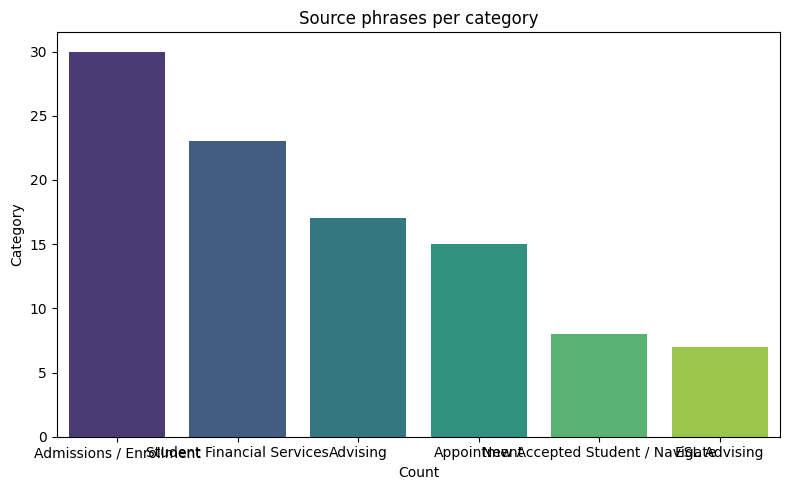

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=phrases_df, x="Category", order=phrases_df["Category"].value_counts().index, palette="viridis")
plt.title("Source phrases per category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [ ]:
print("Source phrase count by category:")
print(phrases_df["Category"].value_counts())

print("\nSource phrase count by subcategory:")
print(phrases_df["Subcategory"].value_counts())

print("\nMissing values check:")
print(phrases_df.isnull().sum())

phrases_df["phrase_length"] = phrases_df["Phrase"].apply(len)
print("\nAvg phrase length by category:")
print(phrases_df.groupby("Category")["phrase_length"].mean().sort_values())

Source phrase count by category:
Category
Admissions / Enrollment            30
Student Financial Services         23
Advising                           17
Appointment                        15
New Accepted Student / Navigate     8
ESL Advising                        7
Name: count, dtype: int64

Source phrase count by subcategory:
Subcategory
Application Assistance                    5
Copy of Transcript                        5
I need an N#                              5
Course Registration                       5
Placement Questions                       5
ESL Advising and Registration             4
Billing, Payments and Refunds             4
International Student Inquiry             3
Verification Letter                       3
Change of Program                         3
Course Withdrawal                         3
Non-credit Registration                   3
Guest Student Course Registration         3
Enrollment Form Completion                3
Admissions/Enrollment Appointment      

Using the same training data, I will generate more training data from the loaded phrases by creating minor variations.

# **SUPERSEEDED!**
See leakage analysis below

In [ ]:
# # Function that generates variants of the pre-existing data

# def augment_phrase(phrase):
#   variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
#   return random.choice(variants)

# #Generative goal of 60 examples per department (combat overfitting)
# TARGET_PER_CATEGORY = 60

# rows = []

# for category in phrases_df["Category"].unique():
#   category_rows = phrases_df[phrases_df["Category"] == category]

#   #Counter - Artificial samples created for current category.
#   generated = 0

#   while generated < TARGET_PER_CATEGORY:

#     sample = category_rows.sample(1).iloc[0]
#     phrase = augment_phrase(sample["Phrase"])
#     rows.append({
#         "text": phrase,
#         "category": sample["Category"],
#         "subcategory": sample["Subcategory"]
#     })
#     generated += 1

# #Create new dataframe for Artificial samples/training data.
# newData = pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)
# newData.to_csv("training_data.csv", index=False)

In [ ]:
def augment_phrase(phrase):
    variants = [phrase, phrase.lower(), phrase + "?", phrase + "."]
    return random.choice(variants)

**Fix: split source phrases before augmenting**

In [ ]:
# Split SOURCE phrases first, before augmenting — this is the fix for the leakage bug (variants of the same phrase can no longer land on both sides)
train_phrases_df, test_phrases_df = train_test_split(
    phrases_df, test_size=0.2, random_state=42, stratify=phrases_df["Category"]
)

# generates augmented examples from a given set of source phrases
def generate_examples(source_df, target_per_category):
    rows = []
    for category in source_df["Category"].unique():
        category_rows = source_df[source_df["Category"] == category]

        #Counter - Artificial samples created for current category.
        generated = 0

        while generated < target_per_category:
            sample = category_rows.sample(1).iloc[0]
            phrase = augment_phrase(sample["Phrase"])
            rows.append({
                "text": phrase,
                "category": sample["Category"],
                "subcategory": sample["Subcategory"]
            })

            generated += 1
    return pd.DataFrame(rows).drop_duplicates(subset="text").reset_index(drop=True)

trainData = generate_examples(train_phrases_df, target_per_category=60)
testData = generate_examples(test_phrases_df, target_per_category=15)

trainData.to_csv("training_data.csv", index=False)

Let's analyze the new data.

In [ ]:
print(trainData.shape)
trainData.head(10)


(200, 3)


,text,category,subcategory
0,I need to register for ESL classes,ESL Advising,ESL Advising and Registration
1,I want to talk to someone about English langua...,ESL Advising,ESL Advising and Registration
2,Necesito registrarme en clases de inglés?,ESL Advising,ESL Advising and Registration
3,i need to register for esl classes,ESL Advising,ESL Advising and Registration
4,what level esl class am i supposed to take,ESL Advising,Placement Questions
5,i have a question about my esl placement test,ESL Advising,Placement Questions
6,I need to register for ESL classes.,ESL Advising,ESL Advising and Registration
7,Quiero hablar sobre cursos de ESL,ESL Advising,ESL Advising and Registration
8,I have a question about my ESL placement test,ESL Advising,Placement Questions
9,i want to talk to someone about english langua...,ESL Advising,ESL Advising and Registration


Taking a look at the data and confirm that there are no missing values.

In [ ]:
trainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   text         200 non-null    object
 1   category     200 non-null    object
 2   subcategory  200 non-null    object
dtypes: object(3)
memory usage: 4.8+ KB


In [ ]:
trainData.describe()

,text,category,subcategory
count,200,200,200
unique,200,6,30
top,I need to register for ESL classes,Admissions / Enrollment,ESL Advising and Registration
freq,1,47,15


Train/Test split

In [ ]:
X_train = trainData["text"]
y_train = trainData["category"]
X_test = testData["text"]
y_test = testData["category"]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(y_train.value_counts())

Train size: 200, Test size: 49
category
Admissions / Enrollment            47
Student Financial Services         41
Advising                           39
Appointment                        31
ESL Advising                       21
New Accepted Student / Navigate    21
Name: count, dtype: int64


Note: **Model will predict Category, will upscale to Sub-Category as well later into development**

Building the pipeline.

In [ ]:
pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        lowercase=True
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

ngram_range=(1, 2) chosen due to two-word pairs carrying more meaning than an individual word can capture.

In [ ]:
print(pipeline)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])


Fitting the pipeline.

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Accuracy check.

In [ ]:
train_accuracy = pipeline.score(X_train, y_train)
test_accuracy = pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Gap: {train_accuracy - test_accuracy:.3f}")

Train Accuracy: 0.985
Test Accuracy: 0.449
Gap: 0.536


FIXED* OLD Results: LEAKAGE

Train Accuracy 1.000, Test Accuracy 1.000, Gap 0.000


Analysis: Perfect score on both sets isn't strong evidence of generalization, I presume the test isn't hard enough yet. augment_phrase() is generating near duplicate variants before the train/test split.

Conclusion/Next Step:

Group by source phrase before splitting, so variants of the same phrase cant land on both sides.

NEW* Results:


Train Accuracy 0.985, Test Accuracy 0.449, Gap 0.536


**Leakage check below:** 0/49 confirmed clean no near duplicates.

**Analysis:** With leakage removed, the real overfitting gap is now visible.

Likely cause: augmentation only varies casing/punctuation, not real diversity in terms of phrasing, with few unique source phrases per subcategory.

**Result:** This confirms the need for LLM generated training data, not only to reach a minimum of 1500 phrases, but specifically add genune diversity per subcategory.

In [ ]:
# checking to see if near duplicate vari. are leaking across the train/test
from difflib import SequenceMatcher

leaks = 0
for test_phrase in X_test:
    for train_phrase in X_train:
        similarity = SequenceMatcher(None, test_phrase.lower(), train_phrase.lower()).ratio()
        if similarity > 0.9:
            leaks += 1
            break
print(f"Test phrases with a near-duplicate in train: {leaks} / {len(X_test)}")

Test phrases with a near-duplicate in train: 0 / 49


FIXED* OLD LEAKGE RESULTS: 42 out of 46 test phrases have near duplicates sitting in train. Model was essentially being tested on data it has already seen.

Further analysis.

In [ ]:
y_pred = pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.38      1.00      0.56        10
                       Advising       0.00      0.00      0.00         9
                    Appointment       1.00      1.00      1.00        10
                   ESL Advising       0.00      0.00      0.00         4
New Accepted Student / Navigate       0.00      0.00      0.00         7
     Student Financial Services       0.40      0.22      0.29         9

                       accuracy                           0.45        49
                      macro avg       0.30      0.37      0.31        49
                   weighted avg       0.36      0.45      0.37        49


Confusion Matrix:
[[10  0  0  0  0  0]
 [ 6  0  0  0  0  3]
 [ 0  0 10  0  0  0]
 [ 0  0  0  0  4  0]
 [ 7  0  0  0  0  0]
 [ 3  0  0  0  4  2]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Appointment and Admissions and enrollment got perfect scores, while Advising had 0 correct (6 advising went into admission and 3 into Financial), ESL had 0 correct, where all went into Navigate, and New Accepted Student/Navigate had 0 correct, were all were thrown into admissions.
Financial had mixed results.

## LLM Data Generation:


Earlier EDA revealed that our 30 subcategories suffer from extreme data thinness (averaging 2-5 source phrases each). The model is overfitting and treating larger departments as dumping grounds.

Instead of recycling the same 5 sentences, I'm going to use a targeted LLM generation (gpt-4o-mini) to create distinct realistic training data.

To prevent the LLM from generating repetitive responses, this script iterates through a matrix of 5 distinct "prompt styles." I'm testing this pipeline on a single subcategory ("Copy of Transcript") to validate JSON parsing, depublication, and phrase quality before scaling to the full dataset.

In [ ]:
!pip install openai

In [ ]:
from google.colab import userdata
import openai

openai.api_key = userdata.get('OPENAI_API_KEY')

One subcategory test

In [ ]:
import json

#matrix of prompts styles we're sending to the LLM
style_prompts = [
    "casual, informal phrasing",
    "phrasing where the student sounds rushed or in a hurry",
    "more formal or polite phrasing",
    "phrases that mention a reason (e.g. transferring schools, applying for a job)",
    "phrases using different vocabulary (e.g. 'academic record' or 'list of my classes' instead of 'transcript')"
]

# our storage
all_phrases = []

for style in style_prompts:
    response = openai.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
            {"role": "user", "content": f"""Generate 20 short English sentences a college student might say at a front desk needing a "Copy of Transcript" (Admissions/Enrollment subcategory).
Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
        ]
    )

    raw = response.choices[0].message.content
    data = json.loads(raw)
    all_phrases.extend(data["phrases"])
    print(f"{style}: {len(data['phrases'])} phrases generated")

print(f"\nTotal phrases generated: {len(all_phrases)}")
unique_phrases = list(dict.fromkeys(all_phrases))
print(f"Total after exact deduplication: {len(unique_phrases)}")

for p in unique_phrases[:15]:
    print("-", p)

casual, informal phrasing: 21 phrases generated
phrasing where the student sounds rushed or in a hurry: 21 phrases generated
more formal or polite phrasing: 20 phrases generated
phrases that mention a reason (e.g. transferring schools, applying for a job): 21 phrases generated
phrases using different vocabulary (e.g. 'academic record' or 'list of my classes' instead of 'transcript'): 21 phrases generated

Total phrases generated: 104
Total after exact deduplication: 103
- Hey, I need a copy of my transcript, can you help me with that?
- Could I grab a copy of my transcript, please?
- Hi, I'm looking to get my transcript printed out.
- Can you print my transcript for me?
- I forgot to bring my transcript, can I get a copy here?
- Could you assist me in getting my transcript?
- I need a transcript copy for a job application.
- Is it possible to get a copy of my transcript today?
- I’m in need of my transcript, where do I go?
- Can I request a copy of my transcript, please?
- What’s the p

Success! Now let's check for near duplicates one more time.

In [ ]:
near_duplicates = 0
checked_pairs = set()

for i, p1 in enumerate(unique_phrases):
    for j, p2 in enumerate(unique_phrases):
        if i < j:
            similarity = SequenceMatcher(None, p1.lower(), p2.lower()).ratio()
            if similarity > 0.85:
                near_duplicates += 1

print(f"Near-duplicate pairs within the 105 generated phrases: {near_duplicates}")

Near-duplicate pairs within the 105 generated phrases: 5


A good result, only 4 of the 105 phrases were considered near duplicates. Let's quickly check these 4 near duplicates.

In [ ]:
for i, p1 in enumerate(unique_phrases):
    for j, p2 in enumerate(unique_phrases):
        if i < j:
            similarity = SequenceMatcher(None, p1.lower(), p2.lower()).ratio()
            if similarity > 0.85:
                print(f"{similarity:.2f} — \"{p1}\"  vs  \"{p2}\"")

0.86 — "I need a transcript copy for a job application."  vs  "I need my transcript for a loan application."
0.87 — "I need my transcript for grad school applications."  vs  "I need my transcript for a loan application."
0.88 — "I would like to request a copy of my transcript, please."  vs  "I would like to formally request a copy of my transcript, if you please."
0.90 — "I need my transcript for my visa application."  vs  "I need my transcript for a loan application."
0.86 — "I need my transcript for a summer program application."  vs  "I need my transcript for a loan application."


Althought they are considered near duplicates, it shows meaningful word swapping which is LEAPS better than the original issue where 42 out of 46 test phrases were near duplicates of training phrases.

Logging cost: Rounded down to $0.00



Now let's test whether or not the 15 LLM generated phrases for "Copy of Transcript" actually improve results.

In [ ]:
new_rows= pd.DataFrame({
    "Category": "Admissions / Enrollment",
    "Subcategory": "Copy of Transcript",
    "Language": "EN",
    "Phrase": unique_phrases,
})

phrases_df_expanded = pd.concat([phrases_df, new_rows], ignore_index=True)
print(f"Original: {len(phrases_df)} phrases, Expanded: {len(phrases_df_expanded)} phrases")

Original: 100 phrases, Expanded: 203 phrases


Let's compare the old data to the new.

In [ ]:
train_phrases_df_v2, test_phrases_df_v2 = train_test_split(
    phrases_df_expanded, test_size=0.2, random_state=42, stratify=phrases_df_expanded["Category"]
)

trainData_v2 = generate_examples(train_phrases_df_v2, target_per_category=60)
testData_v2 = generate_examples(test_phrases_df_v2, target_per_category=15)

print(f"Train size: {len(trainData_v2)}, Test size: {len(testData_v2)}")

Train size: 219, Test size: 57


In [ ]:
X_train_v2 = trainData_v2["text"]
y_train_v2 = trainData_v2["category"]
X_test_v2 = testData_v2["text"]
y_test_v2 = testData_v2["category"]

In [ ]:
pipeline_v2 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v2.fit(X_train_v2, y_train_v2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Now for the results.

In [ ]:
train_acc_v2 = pipeline_v2.score(X_train_v2, y_train_v2)
test_acc_v2 = pipeline_v2.score(X_test_v2, y_test_v2)

print(f"v1 — Train: {train_accuracy:.3f}, Test: {test_accuracy:.3f}, Gap: {train_accuracy - test_accuracy:.3f}")
print(f"v2 — Train: {train_acc_v2:.3f}, Test: {test_acc_v2:.3f}, Gap: {train_acc_v2 - test_acc_v2:.3f}")

v1 — Train: 0.985, Test: 0.449, Gap: 0.536
v2 — Train: 0.995, Test: 0.509, Gap: 0.487


Noticeable improvement, which justifies this method. I'll need to see full 30 sub categories to finalize decision.

In [ ]:

subcategory_pairs = phrases_df[["Category", "Subcategory"]].drop_duplicates().reset_index(drop=True)
print(f"Total subcategories to generate for: {len(subcategory_pairs)}")
subcategory_pairs

Total subcategories to generate for: 31


,Category,Subcategory
0,Admissions / Enrollment,Application Assistance
1,Admissions / Enrollment,Copy of Transcript
2,Admissions / Enrollment,Enrollment Form Completion
3,Admissions / Enrollment,Guest Student Course Registration
4,Admissions / Enrollment,I need an N#
5,Admissions / Enrollment,International Student Inquiry
6,Admissions / Enrollment,Non-credit Registration
7,Admissions / Enrollment,Verification Letter
8,Advising,Change of Program
9,Advising,Course Registration


Created a function that takes a category, subcatgory, and list of 5 personality styles.

It loops through each style and asks OpenAI via API calls to generate 20 sentences for the scenario

try/except block to catch errors and tries again.

Gathers responses into a big list.

In [ ]:
import time

def generate_for_subcategory(category, subcategory, style_prompts):

    phrases = []
    for style in style_prompts:
        for attempt in range(2):  # try once, retry once on failure
            try:
                response = openai.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
                        {"role": "user", "content": f"""Generate 20 short English sentences a college student might say
at a front desk needing help with "{subcategory}" ({category} subcategory).
Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
                    ]
                )
                data = json.loads(response.choices[0].message.content)
                phrases.extend(data["phrases"])
                break  # success, no need to retry
            except (json.JSONDecodeError, KeyError) as e:
                if attempt == 0:
                    print(f"  Retry needed for {subcategory} / {style}: {e}")
                else:
                    print(f"  FAILED after retry: {subcategory} / {style}: {e}")
    return phrases

In [ ]:
#redefine list with 5 different constraints.
style_prompts = [
    "casual, informal phrasing",
    "phrasing where the student sounds rushed or in a hurry",
    "more formal or polite phrasing",
    "phrases that mention a reason (e.g. transferring schools, applying for a job)",
    "phrases using different vocabulary where natural"
]

#master storage
all_generated_rows = []

#loops through 30 unique cat and subcat extracted from original data
for i, row in subcategory_pairs.iterrows():
    category, subcategory = row["Category"], row["Subcategory"]
    #progress bar
    print(f"[{i+1}/{len(subcategory_pairs)}] Generating for: {subcategory} ({category})")

    phrases = generate_for_subcategory(category, subcategory, style_prompts)
    unique = list(dict.fromkeys(phrases))  # dedupe within this subcategory

    for phrase in unique:
        all_generated_rows.append({
            "Category": category,
            "Subcategory": subcategory,
            "Language": "EN",
            "Phrase": phrase
        })

    print(f"  → {len(unique)} unique phrases")

    time.sleep(2)
print(f"\nDone. Total new phrases generated: {len(all_generated_rows)}")

[1/31] Generating for: Application Assistance (Admissions / Enrollment)
  → 105 unique phrases
[2/31] Generating for: Copy of Transcript (Admissions / Enrollment)
  → 105 unique phrases
[3/31] Generating for: Enrollment Form Completion (Admissions / Enrollment)
  → 103 unique phrases
[4/31] Generating for: Guest Student Course Registration (Admissions / Enrollment)
  → 104 unique phrases
[5/31] Generating for: I need an N# (Admissions / Enrollment)
  → 103 unique phrases
[6/31] Generating for: International Student Inquiry (Admissions / Enrollment)
  → 104 unique phrases
[7/31] Generating for: Non-credit Registration (Admissions / Enrollment)
  → 104 unique phrases
[8/31] Generating for: Verification Letter (Admissions / Enrollment)
  → 103 unique phrases
[9/31] Generating for: Change of Program (Advising)
  → 105 unique phrases
[10/31] Generating for: Course Registration (Advising)
  → 105 unique phrases
[11/31] Generating for: Course Withdrawal (Advising)
  → 103 unique phrases
[12/3

In [ ]:
generated_df = pd.DataFrame(all_generated_rows)
generated_df.to_csv("llm_generated_phrases.csv", index=False)

print(f"Saved {len(generated_df)} phrases to llm_generated_phrases.csv")
print("\nPhrases per subcategory:")
print(generated_df["Subcategory"].value_counts())

Saved 3221 phrases to llm_generated_phrases.csv

Phrases per subcategory:
Subcategory
Placement Questions                       209
Application Assistance                    105
Degree Evaluation                         105
Transfer Advising                         105
Change of Program                         105
Copy of Transcript                        105
Admissions/Enrollment Appointment         105
ESL Advising and Registration             105
Advising Appointment                      105
Course Registration                       105
Health Insurance Waiver Assistance        105
Non-credit Registration                   104
International Student Inquiry             104
Guest Student Course Registration         104
SFS General Questions                     104
FAFSA or MASFA Application Assistance     104
Billing, Payments and Refunds             104
Financial Services Appointment            104
Navigate Assistance                       104
Questions about Free Community College  

In [ ]:
generated_df.head()

,Category,Subcategory,Language,Phrase
0,Admissions / Enrollment,Application Assistance,EN,"Hey, can you help me check the status of my ap..."
1,Admissions / Enrollment,Application Assistance,EN,"I need help with my application, like, right now."
2,Admissions / Enrollment,Application Assistance,EN,What’s the next step after I submit my applica...
3,Admissions / Enrollment,Application Assistance,EN,Can you explain how to submit my transcript?
4,Admissions / Enrollment,Application Assistance,EN,"I’m confused about the recommendation letters,..."


In [ ]:
generated_df.tail()

,Category,Subcategory,Language,Phrase
3216,Student Financial Services,SFS General Questions,EN,Can I get help filling out the FAFSA?
3217,Student Financial Services,SFS General Questions,EN,How do I report changes to my financial situat...
3218,Student Financial Services,SFS General Questions,EN,What forms do I need to submit for verification?
3219,Student Financial Services,SFS General Questions,EN,Where can I find information on emergency fina...
3220,Student Financial Services,SFS General Questions,EN,Can you guide me on setting up a payment plan ...


While the rest of the subcategories have 100 examples, "Placement Questions" has 209, let's investigate.

In [ ]:
placement_table = generated_df[generated_df["Subcategory"] == "Placement Questions"]

display(placement_table.sample(15))


,Category,Subcategory,Language,Phrase
1989,ESL Advising,Placement Questions,EN,I'm a bit confused about the ESL program options.
2300,New Accepted Student / Navigate,Placement Questions,EN,Are there any resources available to help me p...
2382,New Accepted Student / Navigate,Placement Questions,EN,What are the different levels for math placement?
2051,ESL Advising,Placement Questions,EN,I received my placement results but don't unde...
2316,New Accepted Student / Navigate,Placement Questions,EN,"I’m really anxious about my course placements,..."
2298,New Accepted Student / Navigate,Placement Questions,EN,Can you explain the different levels of classe...
2347,New Accepted Student / Navigate,Placement Questions,EN,Would it be possible for you to explain the ti...
2313,New Accepted Student / Navigate,Placement Questions,EN,What’s the deadline for placement question sub...
2320,New Accepted Student / Navigate,Placement Questions,EN,Is there a fast way to complete my placement q...
2329,New Accepted Student / Navigate,Placement Questions,EN,"I have a meeting soon, so I need quick answers..."


It seems that ESL and Navigate "Placement Questions" got mixed up. Let's sort them out properly.

In [ ]:
#rename ESL cat "Placement Questions" to "ESL Placement Questions"
generated_df.loc[
    (generated_df["Category"] == "ESL Advising") &
    (generated_df["Subcategory"] == "Placement Questions"),
    "Subcategory"
] = "ESL Placement Questions"

generated_df.to_csv("llm_generated_phrases.csv", index=False)

print(generated_df["Subcategory"].value_counts())

Subcategory
Application Assistance                    105
Copy of Transcript                        105
Admissions/Enrollment Appointment         105
Degree Evaluation                         105
Transfer Advising                         105
Course Registration                       105
Change of Program                         105
Advising Appointment                      105
Health Insurance Waiver Assistance        105
ESL Placement Questions                   105
ESL Advising and Registration             105
Navigate Assistance                       104
Guest Student Course Registration         104
International Student Inquiry             104
Non-credit Registration                   104
SFS General Questions                     104
FAFSA or MASFA Application Assistance     104
Billing, Payments and Refunds             104
Financial Services Appointment            104
Placement Questions                       104
Questions about Free Community College    104
Enrollment Form Comple

Success!

Now let's perform EDA on the generated phrases to check of distribution, missing values, phrases length.

In [ ]:
generated_df = pd.read_csv("llm_generated_phrases.csv")
generated_df["phrase_length"] = generated_df["Phrase"].apply(len)

## Chart

/tmp/ipykernel_5676/2598250375.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


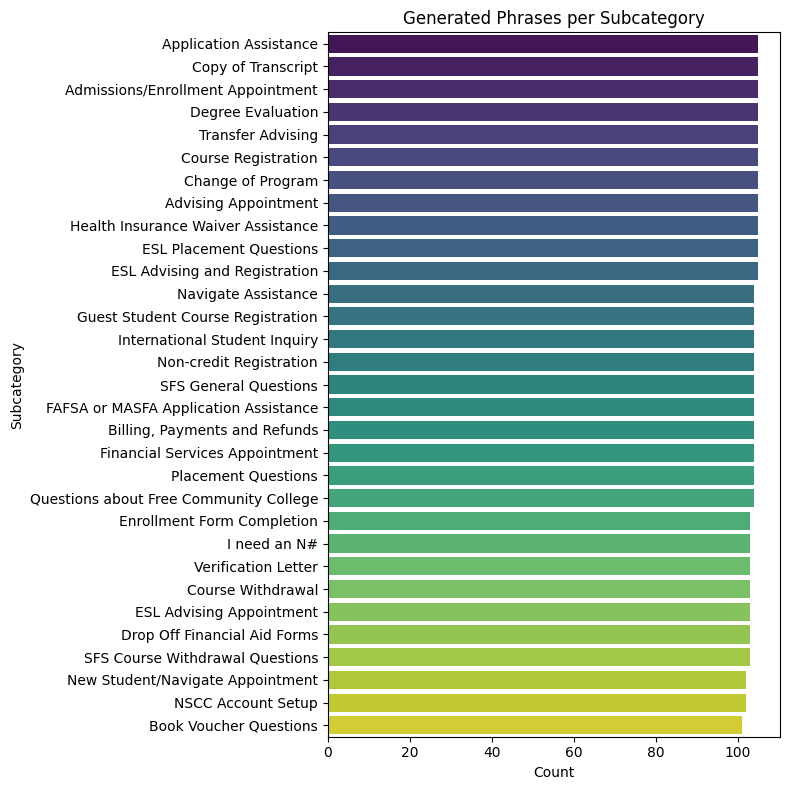

In [ ]:
plt.figure(figsize=(8, 8))
sns.countplot(
    data=generated_df,
    y="Subcategory",
    order=generated_df["Subcategory"].value_counts().index,
    palette="viridis"
)
plt.title("Generated Phrases per Subcategory")
plt.xlabel("Count")
plt.ylabel("Subcategory")
plt.tight_layout()
plt.show()

## Counts

In [ ]:
print("Phrase count by subcategory:")
print(generated_df["Subcategory"].value_counts())

print("\nPhrase count by category (rolled up):")
print(generated_df["Category"].value_counts())

Phrase count by subcategory:
Subcategory
Application Assistance                    105
Copy of Transcript                        105
Admissions/Enrollment Appointment         105
Degree Evaluation                         105
Transfer Advising                         105
Course Registration                       105
Change of Program                         105
Advising Appointment                      105
Health Insurance Waiver Assistance        105
ESL Placement Questions                   105
ESL Advising and Registration             105
Navigate Assistance                       104
Guest Student Course Registration         104
International Student Inquiry             104
Non-credit Registration                   104
SFS General Questions                     104
FAFSA or MASFA Application Assistance     104
Billing, Payments and Refunds             104
Financial Services Appointment            104
Placement Questions                       104
Questions about Free Community College 

## Data Quality Check

In [ ]:
generated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3221 entries, 0 to 3220
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       3221 non-null   object
 1   Subcategory    3221 non-null   object
 2   Language       3221 non-null   object
 3   Phrase         3221 non-null   object
 4   phrase_length  3221 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 125.9+ KB


In [ ]:
print("\nMissing values check:")
print(generated_df.isnull().sum())

print("\nAvg phrase length by subcategory (min/max to spot outliers):")
length_stats = generated_df.groupby("Subcategory")["phrase_length"].agg(["mean", "min", "max"])
print(length_stats.sort_values("mean"))


Missing values check:
Category         0
Subcategory      0
Language         0
Phrase           0
phrase_length    0
dtype: int64

Avg phrase length by subcategory (min/max to spot outliers):
                                             mean  min  max
Subcategory                                                
I need an N#                            45.407767   23   74
ESL Advising and Registration           53.980952   34   79
Copy of Transcript                      56.771429   34   93
Billing, Payments and Refunds           57.365385   28   90
FAFSA or MASFA Application Assistance   58.048077   37   81
Application Assistance                  58.238095   37   88
Transfer Advising                       58.904762   37   96
NSCC Account Setup                      59.607843   38   90
Book Voucher Questions                  59.821782   33  105
ESL Placement Questions                 59.961905   33   98
Degree Evaluation                       60.828571   37  102
SFS General Questions      

Now that the EDA is complete, let's merge, retrain and then measure.

In [ ]:
generated_df_renamed = generated_df.rename(columns={
    "Category": "Category", "Subcategory": "Subcategory",
    "Language": "Language", "Phrase": "Phrase"
})

In [ ]:
phrases_df_full = pd.concat([phrases_df, generated_df_renamed], ignore_index=True)
print(f"Original: {len(phrases_df)}, Full expanded: {len(phrases_df_full)}")

Original: 100, Full expanded: 3321


In [ ]:
train_phrases_df_v3, test_phrases_df_v3 = train_test_split(
    phrases_df_full, test_size=0.2, random_state=42, stratify=phrases_df_full["Category"]
)

trainData_v3 = generate_examples(train_phrases_df_v3, target_per_category=60)
testData_v3 = generate_examples(test_phrases_df_v3, target_per_category=15)

In [ ]:
X_train_v3 = trainData_v3["text"]
y_train_v3 = trainData_v3["category"]
X_test_v3 = testData_v3["text"]
y_test_v3 = testData_v3["category"]

pipeline_v3 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v3.fit(X_train_v3, y_train_v3)

train_acc_v3 = pipeline_v3.score(X_train_v3, y_train_v3)
test_acc_v3 = pipeline_v3.score(X_test_v3, y_test_v3)

print(f"v1 (baseline)        — Test: {test_accuracy:.3f}, Gap: {train_accuracy - test_accuracy:.3f}")
print(f"v2 (1 subcategory)   — Test: {test_acc_v2:.3f}, Gap: {train_acc_v2 - test_acc_v2:.3f}")
print(f"v3 (all 30 subcats)  — Test: {test_acc_v3:.3f}, Gap: {train_acc_v3 - test_acc_v3:.3f}")

v1 (baseline)        — Test: 0.449, Gap: 0.536
v2 (1 subcategory)   — Test: 0.509, Gap: 0.487
v3 (all 30 subcats)  — Test: 0.753, Gap: 0.244


As the results show the baseline phrases from version 1 of the model show a gap of 0.536, while our tested version 2 of a single subcategory showed a gap of 0.487, and finally version 3, which was tested on all 30 subcategories shows significant improvement.

I'm going to use a Confusion matrix to measure where exactly the errors are concentrated.

In [ ]:
y_pred_v3 = pipeline_v3.predict(X_test_v3)
print(classification_report(y_test_v3, y_pred_v3))

labels = sorted(y_test_v3.unique())
cm = confusion_matrix(y_test_v3, y_pred_v3, labels=labels)



                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.85      0.73      0.79        15
                       Advising       0.54      0.87      0.67        15
                    Appointment       0.87      0.87      0.87        15
                   ESL Advising       0.83      0.67      0.74        15
New Accepted Student / Navigate       0.77      0.71      0.74        14
     Student Financial Services       0.83      0.67      0.74        15

                       accuracy                           0.75        89
                      macro avg       0.78      0.75      0.76        89
                   weighted avg       0.78      0.75      0.76        89



In [ ]:
print(confusion_matrix(y_test_v3, y_pred_v3))

[[11  3  0  0  0  1]
 [ 0 13  2  0  0  0]
 [ 0  0 13  0  1  1]
 [ 0  3  0 10  2  0]
 [ 0  2  0  2 10  0]
 [ 2  3  0  0  0 10]]


Evaluation:

Overall accuracy 0.75, gap 0.244.

Advising precision 0.54.

Advising Category is acting as a dump for ambiguous phrases.
ESL and Financial Services show moderate recall gaps (0.67),although precision remains strong.

Conclusion: Remaining error is concentrated, not random, Advising phrases most likely overlaps too much in terms of vocabulary with neighboring categories. Next step: Targetting review/possible regeneration of Advising phrases for more distinctive languages.

This regeneration will explicitly instruct the LLM on what each subcategory is and is not.

In [ ]:
advising_contrast_prompts = {
    "Course Registration": {
        "is": "an already-enrolled student scheduling their own courses for the upcoming semester with their advisor",
        "is_not": "a guest or non-enrolled student registering for a single course without full enrollment"
    },
    "Course Withdrawal": {
        "is": "the academic process of dropping or withdrawing from a course",
        "is_not": "asking about financial aid, billing, or refund impact of dropping a course"
    },
    "Change of Program": {
        "is": "an already-enrolled student wanting to switch their major or program of study",
        "is_not": "filling out a guest registration form or non-credit enrollment paperwork"
    },
    "Degree Evaluation": {
        "is": "checking how many credits or requirements remain before graduating from this school",
        "is_not": "asking about transferring to a different school"
    },
    "Transfer Advising": {
        "is": "a student wanting to transfer to a different school entirely",
        "is_not": "checking their remaining credits/requirements at their current school"
    },
}

In [ ]:
def generate_contrastive(subcategory, is_desc, is_not_desc, style_prompts):
    phrases = []
    for style in style_prompts:
        for attempt in range(2):
            try:
                response = openai.chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[
                        {"role": "system", "content": "You generate short, realistic student front-desk requests for a college admissions office. Return ONLY valid JSON, no markdown."},
                        {"role": "user", "content": f"""Generate 20 short English sentences a college student might say
at a front desk needing help with "{subcategory}" (an Advising subcategory).

This is specifically about: {is_desc}.
It is NOT about: {is_not_desc} — do not generate phrases that could be confused with that.

Style: {style}.
Return as JSON: {{"phrases": ["...", "...", ...]}}"""}
                    ]
                )
                data = json.loads(response.choices[0].message.content)
                phrases.extend(data["phrases"])
                break
            except (json.JSONDecodeError, KeyError) as e:
                if attempt == 1:
                    print(f"  FAILED: {subcategory} / {style}: {e}")
    return phrases

In [ ]:
advising_rows = []
for subcat, contrast in advising_contrast_prompts.items():
    print(f"Generating: {subcat}")
    phrases = generate_contrastive(subcat, contrast["is"], contrast["is_not"], style_prompts)
    unique = list(dict.fromkeys(phrases))
    print(f"  → {len(unique)} unique phrases")
    for p in unique:
        advising_rows.append({
            "Category": "Advising",
            "Subcategory": subcat,
            "Language": "EN",
            "Phrase": p
        })

advising_contrastive_df = pd.DataFrame(advising_rows)
advising_contrastive_df.to_csv("advising_contrastive_phrases.csv", index=False)
print(f"\nTotal new contrastive Advising phrases: {len(advising_contrastive_df)}")

Generating: Course Registration
  → 102 unique phrases
Generating: Course Withdrawal
  → 103 unique phrases
Generating: Change of Program
  → 105 unique phrases
Generating: Degree Evaluation
  → 104 unique phrases
Generating: Transfer Advising
  → 105 unique phrases

Total new contrastive Advising phrases: 519


Let's inspect the new file.

In [ ]:
advising_contrastive_df = pd.read_csv("advising_contrastive_phrases.csv")

print(f"Total: {len(advising_contrastive_df)}")
print(advising_contrastive_df["Subcategory"].value_counts())

print("\n Sample phrases per subcategory")
for subcat in advising_contrastive_df["Subcategory"].unique():
    print(f"\n{subcat}:")
    sample = advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat]["Phrase"].sample(min(8, len(advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat])))
    for p in sample:
        print(f"  - {p}")

Total: 519
Subcategory
Change of Program      105
Transfer Advising      105
Degree Evaluation      104
Course Withdrawal      103
Course Registration    102
Name: count, dtype: int64

 Sample phrases per subcategory

Course Registration:
  - I'm having trouble arranging my classes; can you assist me?
  - I would like to ensure my course registration aligns with my academic goals; can you facilitate scheduling an advisor meeting?
  - I need to finalize my course registration and would appreciate assistance in scheduling an advisor meeting.
  - Could I get assistance with my degree plan and course registration?
  - I want to schedule a meeting with my advisor to discuss my course registration.
  - Could you provide me with the necessary steps to schedule a meeting with my advisor for course selection?
  - I need to meet with my advisor to finalize my courses for next semester!
  - Do you know if my advisor has any slots open this week?

Course Withdrawal:
  - I need to drop a class beca

Excellent!

Although, after manual review, 2 phrases stuck out as possibly confusing, I will drop these two.

In [ ]:
phrases_to_drop = [
    "Could I get assistance with my degree plan and course registration?",
    "I'm planning my schedule for next semester and need to know my remaining credits."
]

In [ ]:
print(f"Total: {len(advising_contrastive_df)}")
print(advising_contrastive_df["Subcategory"].value_counts())

print("\n Sample phrases per subcategory")
for subcat in advising_contrastive_df["Subcategory"].unique():
    print(f"\n{subcat}:")
    sample = advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat]["Phrase"].sample(min(8, len(advising_contrastive_df[advising_contrastive_df["Subcategory"] == subcat])))
    for p in sample:
        print(f"  - {p}")

Total: 518
Subcategory
Change of Program      105
Transfer Advising      105
Degree Evaluation      104
Course Withdrawal      103
Course Registration    101
Name: count, dtype: int64

 Sample phrases per subcategory

Course Registration:
  - Can you help me understand my course registration timeline?
  - I'm on a deadline for course registration; when can I meet with my advisor?
  - Could you tell me when I can meet with my advisor to plan my courses?
  - Is there an open slot for me to meet my advisor about courses this week?
  - Can I ask how to fit in my electives during the advising appointment?
  - I would like to discuss my course options for next semester with my advisor.
  - I need to make sure my course schedule aligns with my major requirements.
  - Could you assist me in arranging a meeting with my academic advisor about course registration?

Course Withdrawal:
  - What deadlines should I be aware of for course withdrawals?
  - Can you assist me in the withdrawal process? I

let's merge, split, then augment.

In [ ]:
phrases_df_v4 = phrases_df_full[phrases_df_full["Category"] != "Advising"].copy()
phrases_df_v4 = pd.concat([phrases_df_v4, advising_contrastive_df], ignore_index=True)

print(f"phrases_df_full: {len(phrases_df_full)}")
print(f"phrases_df_v4 (Advising replaced): {len(phrases_df_v4)}")

train_phrases_df_v4, test_phrases_df_v4 = train_test_split(
    phrases_df_v4, test_size=0.2, random_state=42, stratify=phrases_df_v4["Category"]
)
trainData_v4 = generate_examples(train_phrases_df_v4, target_per_category=60)
testData_v4 = generate_examples(test_phrases_df_v4, target_per_category=15)

phrases_df_full: 3321
phrases_df_v4 (Advising replaced): 3299


fit pipeline v4

In [ ]:
X_train_v4 = trainData_v4["text"]
y_train_v4 = trainData_v4["category"]
X_test_v4 = testData_v4["text"]
y_test_v4 = testData_v4["category"]

pipeline_v4 = Pipeline([
    ("vectorizer", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, lowercase=True)),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
pipeline_v4.fit(X_train_v4, y_train_v4)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](6,)","['Admissions / Enrollment','Advising','Appointment','ESL Advising', 'New Accepted Student / Navigate','Student Financial Services']"
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


let's evaluate.

In [ ]:
y_pred_v4 = pipeline_v4.predict(X_test_v4)
print(classification_report(y_test_v4, y_pred_v4))

print(confusion_matrix(y_test_v4, y_pred_v4, labels=labels))

                                 precision    recall  f1-score   support

        Admissions / Enrollment       0.71      0.67      0.69        15
                       Advising       0.61      0.73      0.67        15
                    Appointment       0.60      0.86      0.71        14
                   ESL Advising       0.64      0.64      0.64        14
New Accepted Student / Navigate       0.88      0.47      0.61        15
     Student Financial Services       0.64      0.60      0.62        15

                       accuracy                           0.66        88
                      macro avg       0.68      0.66      0.66        88
                   weighted avg       0.68      0.66      0.66        88

[[10  2  0  0  0  3]
 [ 0 11  2  1  0  1]
 [ 2  0 12  0  0  0]
 [ 0  1  3  9  0  1]
 [ 2  1  1  4  7  0]
 [ 0  3  2  0  1  9]]


While advising results improved, other results have worsened.